# Fin-JEPA Fraud Detection on AMLSim

## Experiment Overview

This notebook implements and evaluates a Fin-JEPA-based approach for fraud detection using the AMLSim dataset.

The experiment consists of:

1. Loading the AMLSim dataset.
2. Constructing account-level transaction histories.
3. Engineering transaction-level features.
4. Splitting accounts into training, validation, and test sets.
5. Building sequential transaction windows.
6. Pretraining the Fin-JEPA model.
7. Extracting learned representations.
8. Training downstream fraud classifiers.
9. Evaluating fraud-detection performance.

This notebook is the executable source for reproducing the AMLSim experiment.

The accompanying `README.md` and `RESULTS.md` document the methodology, configuration, and reported results.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset/accounts.csv
/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset/alerts.csv
/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset/transactions.csv


In [2]:
# ── model.py (fixed for Kaggle/CUDA) ──
import math
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


class SIGReg(nn.Module):
    """Stops the model from collapsing all outputs into one lazy, identical value."""
    def __init__(self, knots=17, num_proj=512):
        super().__init__()
        self.num_proj = num_proj
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj):
        A = torch.randn(proj.size(-1), self.num_proj, device=proj.device)
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        statistic = (err @ self.weights) * proj.size(-2)
        return statistic.mean()


class PriceEncoder(nn.Module):
    """Squishes one row of features (a 'day', or in our case a transaction) into a 64-number fingerprint."""
    def __init__(self, n_features, embed_dim=64, hidden_dim=128, n_layers=3, n_heads=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, embed_dim)
        self.encoder = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, x):
        x = self.input_proj(x.squeeze(1))
        x = self.encoder(x)
        x = self.projector(x)
        return x


class TransformerPredictor(nn.Module):
    """Looks at a sequence of fingerprints and predicts the next ones (causal — no peeking ahead)."""
    def __init__(self, embed_dim=64, n_layers=4, n_heads=4, mlp_scale=4, dropout=0.1, max_seq_len=256):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, max_seq_len, embed_dim) * 0.02)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=n_heads,
                dim_feedforward=embed_dim * mlp_scale,
                dropout=dropout, activation='gelu', batch_first=True, norm_first=True
            ) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.pred_proj = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Linear(embed_dim, embed_dim),
            nn.GELU(), nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, z_seq):
        B, T, D = z_seq.shape
        x = z_seq + self.pos_embed[:, :T, :]
        x = self.dropout(x)
        mask = torch.triu(torch.full((T, T), float('-inf'), device=z_seq.device), diagonal=1)
        for block in self.blocks:
            x = block(x, src_mask=mask, is_causal=False)
        x = self.norm(x)
        x = self.pred_proj(x)
        return x


class FinJEPA(nn.Module):
    """The full model: encoder + predictor + anti-collapse regularizer."""
    def __init__(self, n_features, embed_dim=64, encoder_layers=3, encoder_heads=3,
                 predictor_layers=4, predictor_heads=4, sigreg_proj=512, sigreg_lambda=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.sigreg_lambda = sigreg_lambda
        self.encoder = PriceEncoder(n_features, embed_dim, n_layers=encoder_layers, n_heads=encoder_heads)
        self.predictor = TransformerPredictor(embed_dim, predictor_layers, predictor_heads)
        self.sigreg = SIGReg(num_proj=sigreg_proj)

    def encode_batch(self, seq):
        B, T, F = seq.shape
        z_all = self.encoder(seq.reshape(-1, 1, F).squeeze(1))
        return z_all.reshape(B, T, -1)

    def forward(self, ctx, tgt=None):
        B, T_ctx, F = ctx.shape
        z_ctx = self.encode_batch(ctx)
        z_pred = self.predictor(z_ctx)
        output = {'emb': z_ctx}

        if tgt is not None:
            z_tgt = self.encode_batch(tgt)
            n_compare = min(T_ctx, tgt.shape[1])
            pred_loss = torch.nn.functional.mse_loss(z_pred[:, :n_compare], z_tgt[:, :n_compare])
            output['pred_loss'] = pred_loss
            full_emb = torch.cat([z_ctx, z_tgt], dim=1)
            sigreg_loss = self.sigreg(full_emb.permute(1, 0, 2))
            output['sigreg_loss'] = sigreg_loss
            output['loss'] = pred_loss + self.sigreg_lambda * sigreg_loss

        return output

    def predict_future(self, ctx, n_steps=10):
        z_ctx = self.encode_batch(ctx)
        current = z_ctx
        preds = []
        for _ in range(n_steps):
            z_pred_all = self.predictor(current)
            z_next = z_pred_all[:, -1:]
            preds.append(z_next)
            current = torch.cat([current, z_next], dim=1)
        return torch.cat(preds, dim=1)


class LinearProbe(nn.Module):
    """Tiny classifier we attach AFTER training, to test if the learned fingerprints are useful for fraud detection."""
    def __init__(self, embed_dim, output_dim=1):
        super().__init__()
        self.probe = nn.Linear(embed_dim, output_dim)

    def forward(self, z):
        return self.probe(z)


class MLPProbe(nn.Module):
    def __init__(self, embed_dim, hidden_dim=32, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z):
        return self.net(z)


# Sanity check — run this to confirm everything works before moving on
model = FinJEPA(n_features=11, embed_dim=64).to(DEVICE)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
ctx = torch.randn(4, 60, 11, device=DEVICE)
tgt = torch.randn(4, 5, 11, device=DEVICE)
out = model(ctx, tgt)
print(f"Forward: loss={out['loss']:.4f} (pred={out['pred_loss']:.4f}, sigreg={out['sigreg_loss']:.4f})")
print("✅ Model OK")

Using device: cuda
Params: 267,328
Forward: loss=0.2242 (pred=0.0589, sigreg=1.6534)
✅ Model OK


In [3]:
import os

# Find the dataset files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset/accounts.csv
/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset/alerts.csv
/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset/transactions.csv


In [4]:
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset"

accounts = pd.read_csv(f"{BASE_PATH}/accounts.csv")
transactions = pd.read_csv(f"{BASE_PATH}/transactions.csv")
alerts = pd.read_csv(f"{BASE_PATH}/alerts.csv")

print("=== accounts.csv ===")
print(accounts.shape)
print(accounts.head())
print()

print("=== transactions.csv ===")
print(transactions.shape)
print(transactions.head())
print()
print(transactions.dtypes)
print()

print("=== IS_FRAUD balance in transactions ===")
print(transactions['IS_FRAUD'].value_counts())
print()

print("=== TIMESTAMP sample values ===")
print(transactions['TIMESTAMP'].head(10).tolist())
print()

print("=== transactions per account (top 10) ===")
print(transactions['SENDER_ACCOUNT_ID'].value_counts().head(10))

=== accounts.csv ===
(10000, 7)
   ACCOUNT_ID CUSTOMER_ID  INIT_BALANCE COUNTRY ACCOUNT_TYPE  IS_FRAUD  \
0           0         C_0        184.44      US            I     False   
1           1         C_1        175.80      US            I     False   
2           2         C_2        142.06      US            I     False   
3           3         C_3        125.89      US            I     False   
4           4         C_4        151.13      US            I     False   

   TX_BEHAVIOR_ID  
0               1  
1               1  
2               1  
3               1  
4               1  

=== transactions.csv ===
(1323234, 8)
   TX_ID  SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID   TX_TYPE  TX_AMOUNT  \
0      1               6456                 9069  TRANSFER     465.05   
1      2               7516                 9543  TRANSFER     564.64   
2      3               2445                 9356  TRANSFER     598.94   
3      4               2576                 4617  TRANSFER     466.07   

In [5]:
print("=== TIMESTAMP range ===")
print("min:", transactions['TIMESTAMP'].min(), "max:", transactions['TIMESTAMP'].max())
print("unique values:", transactions['TIMESTAMP'].nunique())
print()

print("=== TX_TYPE unique values ===")
print(transactions['TX_TYPE'].value_counts())
print()

print("=== Transactions per account: distribution (as sender) ===")
sender_counts = transactions['SENDER_ACCOUNT_ID'].value_counts()
print(sender_counts.describe())
print()
print("Accounts with >= 20 transactions:", (sender_counts >= 20).sum(), "out of", len(sender_counts))
print("Accounts with >= 10 transactions:", (sender_counts >= 10).sum())
print()

print("=== How many accounts appear in fraud transactions? ===")
fraud_tx = transactions[transactions['IS_FRAUD'] == True]
print("Unique fraud sender accounts:", fraud_tx['SENDER_ACCOUNT_ID'].nunique())
print("Unique fraud receiver accounts:", fraud_tx['RECEIVER_ACCOUNT_ID'].nunique())

=== TIMESTAMP range ===
min: 0 max: 199
unique values: 200

=== TX_TYPE unique values ===
TX_TYPE
TRANSFER    1323234
Name: count, dtype: int64

=== Transactions per account: distribution (as sender) ===
count    9999.000000
mean      132.336634
std       132.742247
min         7.000000
25%        22.000000
50%       132.000000
75%       180.000000
max       963.000000
Name: count, dtype: float64

Accounts with >= 20 transactions: 8249 out of 9999
Accounts with >= 10 transactions: 9990

=== How many accounts appear in fraud transactions? ===
Unique fraud sender accounts: 1484
Unique fraud receiver accounts: 1030


In [6]:
import numpy as np

# Combine sent and received into one long table, tagging direction
sent = transactions[['SENDER_ACCOUNT_ID', 'TX_AMOUNT', 'TIMESTAMP', 'IS_FRAUD']].copy()
sent.columns = ['ACCOUNT_ID', 'TX_AMOUNT', 'TIMESTAMP', 'IS_FRAUD']
sent['DIRECTION'] = 1  # 1 = sent money out

received = transactions[['RECEIVER_ACCOUNT_ID', 'TX_AMOUNT', 'TIMESTAMP', 'IS_FRAUD']].copy()
received.columns = ['ACCOUNT_ID', 'TX_AMOUNT', 'TIMESTAMP', 'IS_FRAUD']
received['DIRECTION'] = 0  # 0 = received money in

combined = pd.concat([sent, received], ignore_index=True)
combined = combined.sort_values(['ACCOUNT_ID', 'TIMESTAMP']).reset_index(drop=True)

print("Combined table shape:", combined.shape)
print(combined.head(10))
print()

# Check history length per account now (sent + received)
acct_counts = combined['ACCOUNT_ID'].value_counts()
print(acct_counts.describe())
print()
print("Accounts with >= 20 total transactions:", (acct_counts >= 20).sum(), "out of", len(acct_counts))

Combined table shape: (2646468, 5)
   ACCOUNT_ID  TX_AMOUNT  TIMESTAMP  IS_FRAUD  DIRECTION
0           1      175.8          6     False          1
1           1      175.8         19     False          1
2           1      175.8         38     False          1
3           1      175.8         48     False          1
4           1      175.8         55     False          1
5           1      175.8         66     False          1
6           1      175.8         67     False          1
7           1      175.8         76     False          1
8           1      175.8         98     False          1
9           1      175.8        117     False          1

count    9999.000000
mean      264.673267
std       255.898003
min        11.000000
25%       108.000000
50%       216.000000
75%       309.000000
max      4981.000000
Name: count, dtype: float64

Accounts with >= 20 total transactions: 9964 out of 9999


In [7]:
# Feature engineering: turn raw diary into model-ready numbers
combined = combined.sort_values(['ACCOUNT_ID', 'TIMESTAMP']).reset_index(drop=True)

combined['LOG_AMOUNT'] = np.log1p(combined['TX_AMOUNT'])  # log(1 + amount), handles amount=0 safely
combined['TIME_GAP'] = combined.groupby('ACCOUNT_ID')['TIMESTAMP'].diff().fillna(0)

print(combined[['ACCOUNT_ID', 'TIMESTAMP', 'TX_AMOUNT', 'LOG_AMOUNT', 'TIME_GAP', 'DIRECTION']].head(10))
print()
print("LOG_AMOUNT stats:")
print(combined['LOG_AMOUNT'].describe())
print()
print("TIME_GAP stats:")
print(combined['TIME_GAP'].describe())

   ACCOUNT_ID  TIMESTAMP  TX_AMOUNT  LOG_AMOUNT  TIME_GAP  DIRECTION
0           1          6      175.8    5.175019       0.0          1
1           1         19      175.8    5.175019      13.0          1
2           1         38      175.8    5.175019      19.0          1
3           1         48      175.8    5.175019      10.0          1
4           1         55      175.8    5.175019       7.0          1
5           1         66      175.8    5.175019      11.0          1
6           1         67      175.8    5.175019       1.0          1
7           1         76      175.8    5.175019       9.0          1
8           1         98      175.8    5.175019      22.0          1
9           1        117      175.8    5.175019      19.0          1

LOG_AMOUNT stats:
count    2.646468e+06
mean     4.917915e+00
std      2.019346e+00
min      0.000000e+00
25%      3.216072e+00
50%      5.060758e+00
75%      6.089045e+00
max      1.688239e+01
Name: LOG_AMOUNT, dtype: float64

TIME_GAP sta

In [8]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Split ACCOUNTS (not rows) into train/val/test — 70/15/15
all_accounts = combined['ACCOUNT_ID'].unique()
train_accts, temp_accts = train_test_split(all_accounts, test_size=0.30, random_state=42)
val_accts, test_accts = train_test_split(temp_accts, test_size=0.50, random_state=42)

print(f"Train accounts: {len(train_accts)}, Val: {len(val_accts)}, Test: {len(test_accts)}")

# 2. Compute normalization stats from TRAINING accounts only
train_mask = combined['ACCOUNT_ID'].isin(train_accts)
log_amt_mean = combined.loc[train_mask, 'LOG_AMOUNT'].mean()
log_amt_std = combined.loc[train_mask, 'LOG_AMOUNT'].std()
time_gap_mean = combined.loc[train_mask, 'TIME_GAP'].mean()
time_gap_std = combined.loc[train_mask, 'TIME_GAP'].std()

print(f"LOG_AMOUNT: mean={log_amt_mean:.3f}, std={log_amt_std:.3f}")
print(f"TIME_GAP: mean={time_gap_mean:.3f}, std={time_gap_std:.3f}")

# 3. Apply normalization to the whole table (using train-derived stats)
combined['LOG_AMOUNT_NORM'] = (combined['LOG_AMOUNT'] - log_amt_mean) / log_amt_std
combined['TIME_GAP_NORM'] = (combined['TIME_GAP'] - time_gap_mean) / time_gap_std

FEATURE_COLS = ['LOG_AMOUNT_NORM', 'DIRECTION', 'TIME_GAP_NORM']
N_FEATURES = len(FEATURE_COLS)

# 4. Build sliding windows PER ACCOUNT
def build_windows(df, account_ids, context_len=15, pred_len=5, stride=5):
    """For each account, slide a window across its sorted transaction diary."""
    ctx_list, tgt_list, acct_id_list = [], [], []
    grouped = df[df['ACCOUNT_ID'].isin(account_ids)].groupby('ACCOUNT_ID')

    for acct_id, g in grouped:
        feats = g[FEATURE_COLS].values.astype(np.float32)
        n = len(feats)
        total_len = context_len + pred_len
        if n < total_len:
            continue  # not enough history for this account
        for start in range(0, n - total_len + 1, stride):
            ctx_list.append(feats[start : start + context_len])
            tgt_list.append(feats[start + context_len : start + total_len])
            acct_id_list.append(acct_id)

    return np.stack(ctx_list), np.stack(tgt_list), np.array(acct_id_list)

CONTEXT_LEN, PRED_LEN, STRIDE = 15, 5, 5

train_ctx, train_tgt, train_acct_ids = build_windows(combined, train_accts, CONTEXT_LEN, PRED_LEN, STRIDE)
val_ctx, val_tgt, val_acct_ids = build_windows(combined, val_accts, CONTEXT_LEN, PRED_LEN, STRIDE)
test_ctx, test_tgt, test_acct_ids = build_windows(combined, test_accts, CONTEXT_LEN, PRED_LEN, STRIDE)

print(f"\nTrain windows: {train_ctx.shape}")
print(f"Val windows:   {val_ctx.shape}")
print(f"Test windows:  {test_ctx.shape}")

Train accounts: 6999, Val: 1500, Test: 1500
LOG_AMOUNT: mean=4.921, std=2.017
TIME_GAP: mean=0.741, std=1.422

Train windows: (346574, 15, 3)
Val windows:   (73114, 15, 3)
Test windows:  (75677, 15, 3)


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time

# ── Wrap our numpy arrays in a PyTorch Dataset ──
class WindowDataset(Dataset):
    def __init__(self, ctx, tgt):
        self.ctx = torch.from_numpy(ctx).float()
        self.tgt = torch.from_numpy(tgt).float()

    def __len__(self):
        return len(self.ctx)

    def __getitem__(self, idx):
        return {'ctx': self.ctx[idx], 'tgt': self.tgt[idx]}


train_ds = WindowDataset(train_ctx, train_tgt)
val_ds = WindowDataset(val_ctx, val_tgt)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# ── Build a fresh model sized for OUR data (3 features, not 11) ──
model = FinJEPA(n_features=N_FEATURES, embed_dim=64, sigreg_proj=128).to(DEVICE)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

# ── Optimizer + schedule ──
N_EPOCHS = 20
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

BASE_OUT = "/kaggle/working"
best_val_loss = float('inf')

for epoch in range(N_EPOCHS):
    # -- Training pass --
    model.train()
    train_loss_sum = 0.0
    t0 = time.time()
    for batch in train_loader:
        ctx = batch['ctx'].to(DEVICE)
        tgt = batch['tgt'].to(DEVICE)

        optimizer.zero_grad()
        out = model(ctx, tgt)
        out['loss'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss_sum += out['loss'].item()

    scheduler.step()
    avg_train_loss = train_loss_sum / len(train_loader)

    # -- Validation pass (no learning, just checking) --
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for batch in val_loader:
            ctx = batch['ctx'].to(DEVICE)
            tgt = batch['tgt'].to(DEVICE)
            out = model(ctx, tgt)
            val_loss_sum += out['loss'].item()
    avg_val_loss = val_loss_sum / len(val_loader)

    # -- Save the model if it's the best so far --
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), f"{BASE_OUT}/fin_jepa_best.pt")
        marker = " ← saved (best so far)"
    else:
        marker = ""

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | {elapsed:.1f}s{marker}")

print(f"\n✅ Training done. Best val_loss: {best_val_loss:.4f}")
print(f"Best model saved to: {BASE_OUT}/fin_jepa_best.pt")

Train batches: 1354, Val batches: 286
Params: 266,816
Epoch  1/20 | train_loss=1.7774 | val_loss=5.8264 | 28.6s ← saved (best so far)
Epoch  2/20 | train_loss=1.2096 | val_loss=5.4626 | 27.8s ← saved (best so far)
Epoch  3/20 | train_loss=1.1068 | val_loss=5.1849 | 27.8s ← saved (best so far)
Epoch  4/20 | train_loss=1.0528 | val_loss=5.1335 | 28.0s ← saved (best so far)
Epoch  5/20 | train_loss=1.0160 | val_loss=4.9826 | 28.0s ← saved (best so far)
Epoch  6/20 | train_loss=0.9844 | val_loss=4.9174 | 28.4s ← saved (best so far)
Epoch  7/20 | train_loss=0.9582 | val_loss=4.8160 | 28.2s ← saved (best so far)
Epoch  8/20 | train_loss=0.9400 | val_loss=4.7571 | 28.7s ← saved (best so far)
Epoch  9/20 | train_loss=0.9257 | val_loss=4.7012 | 28.6s ← saved (best so far)
Epoch 10/20 | train_loss=0.9127 | val_loss=4.7057 | 28.4s
Epoch 11/20 | train_loss=0.9027 | val_loss=4.7104 | 28.5s
Epoch 12/20 | train_loss=0.8962 | val_loss=4.7122 | 28.5s
Epoch 13/20 | train_loss=0.8901 | val_loss=4.6186 | 

In [10]:
model.eval()
train_pred_sum, train_sig_sum = 0.0, 0.0
val_pred_sum, val_sig_sum = 0.0, 0.0

with torch.no_grad():
    for batch in train_loader:
        ctx, tgt = batch['ctx'].to(DEVICE), batch['tgt'].to(DEVICE)
        out = model(ctx, tgt)
        train_pred_sum += out['pred_loss'].item()
        train_sig_sum += out['sigreg_loss'].item()

    for batch in val_loader:
        ctx, tgt = batch['ctx'].to(DEVICE), batch['tgt'].to(DEVICE)
        out = model(ctx, tgt)
        val_pred_sum += out['pred_loss'].item()
        val_sig_sum += out['sigreg_loss'].item()

print(f"Train: pred_loss={train_pred_sum/len(train_loader):.4f}, sigreg_loss={train_sig_sum/len(train_loader):.4f}")
print(f"Val:   pred_loss={val_pred_sum/len(val_loader):.4f}, sigreg_loss={val_sig_sum/len(val_loader):.4f}")

Train: pred_loss=0.5888, sigreg_loss=2.7456
Val:   pred_loss=0.5985, sigreg_loss=40.1604


In [11]:
# Merge account-level fraud label (from accounts.csv) with our test windows
fraud_accounts = set(accounts[accounts['IS_FRAUD'] == True]['ACCOUNT_ID'])

model.eval()
per_window_errors = []
per_window_is_fraud_account = []

test_ds = WindowDataset(test_ctx, test_tgt)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

with torch.no_grad():
    idx = 0
    for batch in test_loader:
        ctx, tgt = batch['ctx'].to(DEVICE), batch['tgt'].to(DEVICE)
        z_ctx = model.encode_batch(ctx)
        z_pred = model.predictor(z_ctx)
        z_tgt = model.encode_batch(tgt)

        n_compare = min(z_pred.shape[1], z_tgt.shape[1])
        per_sample_err = ((z_pred[:, :n_compare] - z_tgt[:, :n_compare]) ** 2).mean(dim=[1, 2])
        per_window_errors.extend(per_sample_err.cpu().numpy().tolist())

        batch_size = ctx.shape[0]
        batch_acct_ids = test_acct_ids[idx: idx + batch_size]
        per_window_is_fraud_account.extend([acct in fraud_accounts for acct in batch_acct_ids])
        idx += batch_size

import pandas as pd
result_df = pd.DataFrame({
    'error': per_window_errors,
    'is_fraud_account': per_window_is_fraud_account
})

print(result_df.groupby('is_fraud_account')['error'].describe())

from scipy import stats
normal_err = result_df[result_df['is_fraud_account'] == False]['error']
fraud_err = result_df[result_df['is_fraud_account'] == True]['error']
t_stat, p_val = stats.ttest_ind(fraud_err, normal_err)
print(f"\nT-test: t={t_stat:.3f}, p={p_val:.4e}")

                    count      mean       std       min       25%       50%  \
is_fraud_account                                                              
False             55865.0  0.588190  0.298682  0.004406  0.357557  0.592891   
True              19812.0  0.610539  0.286471  0.005660  0.494125  0.611956   

                       75%       max  
is_fraud_account                      
False             0.755971  1.784112  
True              0.741473  1.561602  

T-test: t=9.145, p=6.0896e-20


In [12]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

# ── Step A: Get one "fingerprint" per window, plus its fraud label ──
def get_embeddings_and_labels(ctx_data, acct_ids, fraud_accounts, model, batch_size=256):
    ds = WindowDataset(ctx_data, ctx_data)  # dummy tgt, we only need ctx here
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_embeddings = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            ctx = batch['ctx'].to(DEVICE)
            z_ctx = model.encode_batch(ctx)          # (B, T, D) — fingerprint per day
            pooled = z_ctx.mean(dim=1)                # (B, D) — average into ONE fingerprint per window
            all_embeddings.append(pooled.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.tensor([1.0 if a in fraud_accounts else 0.0 for a in acct_ids])
    return embeddings, labels

train_emb, train_labels = get_embeddings_and_labels(train_ctx, train_acct_ids, fraud_accounts, model)
val_emb, val_labels = get_embeddings_and_labels(val_ctx, val_acct_ids, fraud_accounts, model)
test_emb, test_labels = get_embeddings_and_labels(test_ctx, test_acct_ids, fraud_accounts, model)

print(f"Train: {train_emb.shape}, fraud={train_labels.sum().item():.0f}/{len(train_labels)}")
print(f"Val:   {val_emb.shape}, fraud={val_labels.sum().item():.0f}/{len(val_labels)}")
print(f"Test:  {test_emb.shape}, fraud={test_labels.sum().item():.0f}/{len(test_labels)}")

# ── Step B: Build and train the probe (small classifier) ──
probe = MLPProbe(embed_dim=64, hidden_dim=32, output_dim=1).to(DEVICE)

# Handle imbalance: tell the loss function "fraud examples are rare, weigh them more"
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(DEVICE)
print(f"\npos_weight (how much extra importance we give fraud examples): {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
probe_optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)

train_emb_dev = train_emb.to(DEVICE)
train_labels_dev = train_labels.to(DEVICE).unsqueeze(1)
val_emb_dev = val_emb.to(DEVICE)
val_labels_dev = val_labels.to(DEVICE).unsqueeze(1)

PROBE_EPOCHS = 30
best_auc = 0.0

for epoch in range(PROBE_EPOCHS):
    probe.train()
    probe_optimizer.zero_grad()
    logits = probe(train_emb_dev)
    loss = criterion(logits, train_labels_dev)
    loss.backward()
    probe_optimizer.step()

    probe.eval()
    with torch.no_grad():
        val_logits = probe(val_emb_dev)
        val_probs = torch.sigmoid(val_logits).cpu().numpy().flatten()
        val_auc = roc_auc_score(val_labels.numpy(), val_probs)

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(probe.state_dict(), "/kaggle/working/probe_best.pt")

    if epoch % 5 == 0 or epoch == PROBE_EPOCHS - 1:
        print(f"Epoch {epoch+1:2d}/{PROBE_EPOCHS} | train_loss={loss.item():.4f} | val_AUC={val_auc:.4f}")

print(f"\n✅ Probe training done. Best val AUC: {best_auc:.4f}")

# ── Step C: Final evaluation on TEST set (never touched until now) ──
probe.load_state_dict(torch.load("/kaggle/working/probe_best.pt"))
probe.eval()
with torch.no_grad():
    test_logits = probe(test_emb.to(DEVICE))
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

test_auc = roc_auc_score(test_labels.numpy(), test_probs)
test_ap = average_precision_score(test_labels.numpy(), test_probs)
print(f"\nFINAL TEST RESULTS:")
print(f"AUC: {test_auc:.4f}")
print(f"Average Precision: {test_ap:.4f}")

Train: torch.Size([346574, 64]), fraud=85290/346574
Val:   torch.Size([73114, 64]), fraud=18504/73114
Test:  torch.Size([75677, 64]), fraud=19812/75677

pos_weight (how much extra importance we give fraud examples): 3.06
Epoch  1/30 | train_loss=1.0504 | val_AUC=0.5594
Epoch  6/30 | train_loss=1.0391 | val_AUC=0.5875
Epoch 11/30 | train_loss=1.0298 | val_AUC=0.6033
Epoch 16/30 | train_loss=1.0220 | val_AUC=0.6144
Epoch 21/30 | train_loss=1.0154 | val_AUC=0.6222
Epoch 26/30 | train_loss=1.0095 | val_AUC=0.6264
Epoch 30/30 | train_loss=1.0052 | val_AUC=0.6288

✅ Probe training done. Best val AUC: 0.6288

FINAL TEST RESULTS:
AUC: 0.6010
Average Precision: 0.3369


In [13]:
def get_embeddings_error_and_labels(ctx_data, tgt_data, acct_ids, fraud_accounts, model, batch_size=256):
    ds = WindowDataset(ctx_data, tgt_data)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_features = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            ctx = batch['ctx'].to(DEVICE)
            tgt = batch['tgt'].to(DEVICE)

            z_ctx = model.encode_batch(ctx)
            z_pred = model.predictor(z_ctx)
            z_tgt = model.encode_batch(tgt)

            pooled = z_ctx.mean(dim=1)  # (B, 64) — the fingerprint, same as before

            n_compare = min(z_pred.shape[1], z_tgt.shape[1])
            per_sample_err = ((z_pred[:, :n_compare] - z_tgt[:, :n_compare]) ** 2).mean(dim=[1, 2], keepdim=True).squeeze(-1)  # (B, 1)

            combined = torch.cat([pooled.cpu(), per_sample_err.cpu()], dim=1)  # (B, 65)
            all_features.append(combined)

    features = torch.cat(all_features, dim=0)
    labels = torch.tensor([1.0 if a in fraud_accounts else 0.0 for a in acct_ids])
    return features, labels

train_feat, train_labels = get_embeddings_error_and_labels(train_ctx, train_tgt, train_acct_ids, fraud_accounts, model)
val_feat, val_labels = get_embeddings_error_and_labels(val_ctx, val_tgt, val_acct_ids, fraud_accounts, model)
test_feat, test_labels = get_embeddings_error_and_labels(test_ctx, test_tgt, test_acct_ids, fraud_accounts, model)

print(f"Train: {train_feat.shape}")  # should now be (N, 65) instead of (N, 64)

# ── Retrain the probe with this richer 65-number input ──
probe2 = MLPProbe(embed_dim=65, hidden_dim=32, output_dim=1).to(DEVICE)

n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
probe2_optimizer = torch.optim.Adam(probe2.parameters(), lr=1e-3)

train_feat_dev = train_feat.to(DEVICE)
train_labels_dev = train_labels.to(DEVICE).unsqueeze(1)
val_feat_dev = val_feat.to(DEVICE)
val_labels_dev = val_labels.to(DEVICE).unsqueeze(1)

best_auc2 = 0.0
for epoch in range(30):
    probe2.train()
    probe2_optimizer.zero_grad()
    logits = probe2(train_feat_dev)
    loss = criterion(logits, train_labels_dev)
    loss.backward()
    probe2_optimizer.step()

    probe2.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(probe2(val_feat_dev)).cpu().numpy().flatten()
        val_auc = roc_auc_score(val_labels.numpy(), val_probs)

    if val_auc > best_auc2:
        best_auc2 = val_auc
        torch.save(probe2.state_dict(), "/kaggle/working/probe2_best.pt")

    if epoch % 5 == 0 or epoch == 29:
        print(f"Epoch {epoch+1:2d}/30 | train_loss={loss.item():.4f} | val_AUC={val_auc:.4f}")

print(f"\n✅ Best val AUC (with error feature): {best_auc2:.4f}")

# ── Final test evaluation ──
probe2.load_state_dict(torch.load("/kaggle/working/probe2_best.pt"))
probe2.eval()
with torch.no_grad():
    test_probs2 = torch.sigmoid(probe2(test_feat.to(DEVICE))).cpu().numpy().flatten()

test_auc2 = roc_auc_score(test_labels.numpy(), test_probs2)
test_ap2 = average_precision_score(test_labels.numpy(), test_probs2)
print(f"\nFINAL TEST RESULTS (with error feature):")
print(f"AUC: {test_auc2:.4f} (previously {test_auc:.4f})")
print(f"Average Precision: {test_ap2:.4f} (previously {test_ap:.4f})")

Train: torch.Size([346574, 65])
Epoch  1/30 | train_loss=1.0440 | val_AUC=0.5591
Epoch  6/30 | train_loss=1.0350 | val_AUC=0.5814
Epoch 11/30 | train_loss=1.0272 | val_AUC=0.5966
Epoch 16/30 | train_loss=1.0202 | val_AUC=0.6085
Epoch 21/30 | train_loss=1.0137 | val_AUC=0.6174
Epoch 26/30 | train_loss=1.0076 | val_AUC=0.6238
Epoch 30/30 | train_loss=1.0029 | val_AUC=0.6282

✅ Best val AUC (with error feature): 0.6282

FINAL TEST RESULTS (with error feature):
AUC: 0.6096 (previously 0.6010)
Average Precision: 0.3385 (previously 0.3369)


In [14]:
import numpy as np
import pandas as pd

def build_account_level_features(ctx_data, tgt_data, acct_ids, model, batch_size=256):
    """For each window, get fingerprint + error. Then GROUP by account and summarize."""
    ds = WindowDataset(ctx_data, tgt_data)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_fingerprints, all_errors = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            ctx = batch['ctx'].to(DEVICE)
            tgt = batch['tgt'].to(DEVICE)
            z_ctx = model.encode_batch(ctx)
            z_pred = model.predictor(z_ctx)
            z_tgt = model.encode_batch(tgt)

            pooled = z_ctx.mean(dim=1)  # (B, 64) fingerprint for this window
            n_compare = min(z_pred.shape[1], z_tgt.shape[1])
            err = ((z_pred[:, :n_compare] - z_tgt[:, :n_compare]) ** 2).mean(dim=[1, 2])  # (B,)

            all_fingerprints.append(pooled.cpu().numpy())
            all_errors.append(err.cpu().numpy())

    fingerprints = np.concatenate(all_fingerprints, axis=0)  # (N_windows, 64)
    errors = np.concatenate(all_errors, axis=0)              # (N_windows,)

    # Now GROUP all windows by their account, and summarize each account's "case file"
    df = pd.DataFrame({'acct': acct_ids, 'error': errors})
    for i in range(fingerprints.shape[1]):
        df[f'fp_{i}'] = fingerprints[:, i]

    grouped = df.groupby('acct')
    fp_cols = [f'fp_{i}' for i in range(fingerprints.shape[1])]

    account_df = pd.DataFrame({
        'acct': grouped.size().index,
        'error_mean': grouped['error'].mean().values,   # average surprise
        'error_max': grouped['error'].max().values,     # WORST single moment
    })
    fp_means = grouped[fp_cols].mean().values  # average fingerprint per account
    account_features = np.concatenate([fp_means, account_df[['error_mean', 'error_max']].values], axis=1)

    return account_features, account_df['acct'].values

# Build one row per account, for each split
train_acct_feat, train_acct_list = build_account_level_features(train_ctx, train_tgt, train_acct_ids, model)
val_acct_feat, val_acct_list = build_account_level_features(val_ctx, val_tgt, val_acct_ids, model)
test_acct_feat, test_acct_list = build_account_level_features(test_ctx, test_tgt, test_acct_ids, model)

train_acct_labels = np.array([1.0 if a in fraud_accounts else 0.0 for a in train_acct_list])
val_acct_labels = np.array([1.0 if a in fraud_accounts else 0.0 for a in val_acct_list])
test_acct_labels = np.array([1.0 if a in fraud_accounts else 0.0 for a in test_acct_list])

print(f"Train accounts: {train_acct_feat.shape}, fraud={train_acct_labels.sum():.0f}/{len(train_acct_labels)}")
print(f"Val accounts:   {val_acct_feat.shape}, fraud={val_acct_labels.sum():.0f}/{len(val_acct_labels)}")
print(f"Test accounts:  {test_acct_feat.shape}, fraud={test_acct_labels.sum():.0f}/{len(test_acct_labels)}")

Train accounts: (6973, 66), fraud=1193/6973
Val accounts:   (1494, 66), fraud=242/1494
Test accounts:  (1497, 66), fraud=247/1497


In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Standardize the account-level features (same reasoning as before: keeps numbers on a fair scale)
feat_mean = train_acct_feat.mean(axis=0)
feat_std = train_acct_feat.std(axis=0) + 1e-8

train_acct_feat_norm = (train_acct_feat - feat_mean) / feat_std
val_acct_feat_norm = (val_acct_feat - feat_mean) / feat_std
test_acct_feat_norm = (test_acct_feat - feat_mean) / feat_std

# Convert to tensors
train_x = torch.tensor(train_acct_feat_norm, dtype=torch.float32).to(DEVICE)
train_y = torch.tensor(train_acct_labels, dtype=torch.float32).unsqueeze(1).to(DEVICE)
val_x = torch.tensor(val_acct_feat_norm, dtype=torch.float32).to(DEVICE)
val_y = torch.tensor(val_acct_labels, dtype=torch.float32).unsqueeze(1).to(DEVICE)
test_x = torch.tensor(test_acct_feat_norm, dtype=torch.float32).to(DEVICE)

# Build a fresh probe sized for 66 inputs (64 fingerprint + error_mean + error_max)
probe3 = MLPProbe(embed_dim=66, hidden_dim=32, output_dim=1).to(DEVICE)

n_pos = train_y.sum().item()
n_neg = len(train_y) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).to(DEVICE)
print(f"pos_weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer3 = torch.optim.Adam(probe3.parameters(), lr=1e-3, weight_decay=1e-4)

best_auc3 = 0.0
for epoch in range(100):
    probe3.train()
    optimizer3.zero_grad()
    logits = probe3(train_x)
    loss = criterion(logits, train_y)
    loss.backward()
    optimizer3.step()

    probe3.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(probe3(val_x)).cpu().numpy().flatten()
        val_auc = roc_auc_score(val_acct_labels, val_probs)

    if val_auc > best_auc3:
        best_auc3 = val_auc
        torch.save(probe3.state_dict(), "/kaggle/working/probe3_best.pt")

    if epoch % 10 == 0 or epoch == 99:
        print(f"Epoch {epoch+1:3d}/100 | train_loss={loss.item():.4f} | val_AUC={val_auc:.4f}")

print(f"\n✅ Best val AUC (account-level): {best_auc3:.4f}")

probe3.load_state_dict(torch.load("/kaggle/working/probe3_best.pt"))
probe3.eval()
with torch.no_grad():
    test_probs3 = torch.sigmoid(probe3(test_x)).cpu().numpy().flatten()

test_auc3 = roc_auc_score(test_acct_labels, test_probs3)
test_ap3 = average_precision_score(test_acct_labels, test_probs3)
print(f"\nFINAL TEST RESULTS (account-level):")
print(f"AUC: {test_auc3:.4f}")
print(f"Average Precision: {test_ap3:.4f}")

pos_weight: 4.84
Epoch   1/100 | train_loss=1.1500 | val_AUC=0.5609
Epoch  11/100 | train_loss=1.1250 | val_AUC=0.6029
Epoch  21/100 | train_loss=1.1077 | val_AUC=0.6139
Epoch  31/100 | train_loss=1.0933 | val_AUC=0.6171
Epoch  41/100 | train_loss=1.0803 | val_AUC=0.6197
Epoch  51/100 | train_loss=1.0682 | val_AUC=0.6215
Epoch  61/100 | train_loss=1.0571 | val_AUC=0.6230
Epoch  71/100 | train_loss=1.0472 | val_AUC=0.6264
Epoch  81/100 | train_loss=1.0385 | val_AUC=0.6298
Epoch  91/100 | train_loss=1.0306 | val_AUC=0.6344
Epoch 100/100 | train_loss=1.0240 | val_AUC=0.6393

✅ Best val AUC (account-level): 0.6393

FINAL TEST RESULTS (account-level):
AUC: 0.6550
Average Precision: 0.3095


In [16]:
# Fresh probe, same setup, just training for much longer
probe4 = MLPProbe(embed_dim=66, hidden_dim=32, output_dim=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer4 = torch.optim.Adam(probe4.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS_LONG = 500
best_auc4 = 0.0
patience = 50          # if no improvement for 50 epochs in a row, stop early
epochs_no_improve = 0

for epoch in range(N_EPOCHS_LONG):
    probe4.train()
    optimizer4.zero_grad()
    logits = probe4(train_x)
    loss = criterion(logits, train_y)
    loss.backward()
    optimizer4.step()

    probe4.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(probe4(val_x)).cpu().numpy().flatten()
        val_auc = roc_auc_score(val_acct_labels, val_probs)

    if val_auc > best_auc4:
        best_auc4 = val_auc
        torch.save(probe4.state_dict(), "/kaggle/working/probe4_best.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 25 == 0 or epoch == N_EPOCHS_LONG - 1:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS_LONG} | train_loss={loss.item():.4f} | val_AUC={val_auc:.4f} | best={best_auc4:.4f}")

    if epochs_no_improve >= patience:
        print(f"\nStopped early at epoch {epoch+1} — no improvement for {patience} epochs")
        break

print(f"\n✅ Best val AUC (longer training): {best_auc4:.4f}")

probe4.load_state_dict(torch.load("/kaggle/working/probe4_best.pt"))
probe4.eval()
with torch.no_grad():
    test_probs4 = torch.sigmoid(probe4(test_x)).cpu().numpy().flatten()

test_auc4 = roc_auc_score(test_acct_labels, test_probs4)
test_ap4 = average_precision_score(test_acct_labels, test_probs4)
print(f"\nFINAL TEST RESULTS (longer training):")
print(f"AUC: {test_auc4:.4f} (previous: 0.6655)")
print(f"Average Precision: {test_ap4:.4f} (previous: 0.3215)")

Epoch   1/500 | train_loss=1.1647 | val_AUC=0.4873 | best=0.4873
Epoch  26/500 | train_loss=1.1068 | val_AUC=0.5980 | best=0.5980
Epoch  51/500 | train_loss=1.0760 | val_AUC=0.6133 | best=0.6133
Epoch  76/500 | train_loss=1.0506 | val_AUC=0.6247 | best=0.6247
Epoch 101/500 | train_loss=1.0305 | val_AUC=0.6356 | best=0.6356
Epoch 126/500 | train_loss=1.0122 | val_AUC=0.6442 | best=0.6442
Epoch 151/500 | train_loss=0.9941 | val_AUC=0.6528 | best=0.6528
Epoch 176/500 | train_loss=0.9764 | val_AUC=0.6579 | best=0.6579
Epoch 201/500 | train_loss=0.9593 | val_AUC=0.6629 | best=0.6629
Epoch 226/500 | train_loss=0.9430 | val_AUC=0.6676 | best=0.6677
Epoch 251/500 | train_loss=0.9272 | val_AUC=0.6697 | best=0.6697
Epoch 276/500 | train_loss=0.9116 | val_AUC=0.6722 | best=0.6724
Epoch 301/500 | train_loss=0.8958 | val_AUC=0.6727 | best=0.6727
Epoch 326/500 | train_loss=0.8803 | val_AUC=0.6732 | best=0.6732
Epoch 351/500 | train_loss=0.8650 | val_AUC=0.6736 | best=0.6736
Epoch 376/500 | train_los

In [17]:
import pandas as pd
import numpy as np

# ── Feature 1-4: transaction count, amount stats, sent/received ratio ──
acct_stats = combined.groupby('ACCOUNT_ID').agg(
    tx_count=('LOG_AMOUNT', 'count'),
    amt_mean=('LOG_AMOUNT', 'mean'),
    amt_std=('LOG_AMOUNT', 'std'),
    amt_max=('LOG_AMOUNT', 'max'),
    sent_ratio=('DIRECTION', 'mean'),  # fraction of transactions where money went OUT
).fillna(0)

# ── Feature 5: how many DIFFERENT people did this account interact with? ──
edges_out = transactions[['SENDER_ACCOUNT_ID', 'RECEIVER_ACCOUNT_ID']].rename(
    columns={'SENDER_ACCOUNT_ID': 'ACCOUNT_ID', 'RECEIVER_ACCOUNT_ID': 'PARTNER_ID'})
edges_in = transactions[['RECEIVER_ACCOUNT_ID', 'SENDER_ACCOUNT_ID']].rename(
    columns={'RECEIVER_ACCOUNT_ID': 'ACCOUNT_ID', 'SENDER_ACCOUNT_ID': 'PARTNER_ID'})
all_edges = pd.concat([edges_out, edges_in], ignore_index=True).drop_duplicates()
partner_counts = all_edges.groupby('ACCOUNT_ID')['PARTNER_ID'].nunique().rename('n_partners')

acct_stats = acct_stats.join(partner_counts).fillna(0)
acct_stats['log_tx_count'] = np.log1p(acct_stats['tx_count'])
acct_stats['log_n_partners'] = np.log1p(acct_stats['n_partners'])

RAW_FEATURE_COLS = ['log_tx_count', 'amt_mean', 'amt_std', 'amt_max', 'sent_ratio', 'log_n_partners']
print(acct_stats[RAW_FEATURE_COLS].describe())

# ── Combine these new raw features with our EXISTING model-derived features ──
def combine_features(model_feat, acct_list, acct_stats_df):
    raw_feat = acct_stats_df.loc[acct_list, RAW_FEATURE_COLS].values
    return np.concatenate([model_feat, raw_feat], axis=1)

train_full_feat = combine_features(train_acct_feat, train_acct_list, acct_stats)
val_full_feat = combine_features(val_acct_feat, val_acct_list, acct_stats)
test_full_feat = combine_features(test_acct_feat, test_acct_list, acct_stats)

print(f"\nNew combined feature size: {train_full_feat.shape[1]} (was 66, now +6 = {66+6})")

       log_tx_count     amt_mean      amt_std      amt_max   sent_ratio  \
count   9999.000000  9999.000000  9999.000000  9999.000000  9999.000000   
mean       5.267940     5.134285     1.873540    14.048677     0.500787   
std        0.796189     1.347823     1.175900     4.159911     0.270809   
min        2.484907     2.200754     0.000000     2.769459     0.012637   
25%        4.691348     4.423262     1.115094    13.457569     0.233766   
50%        5.379897     5.083658     1.515157    16.188523     0.567839   
75%        5.736572     5.788968     2.197333    16.882392     0.733333   
max        8.513587    15.152731     6.566480    16.882392     1.000000   

       log_n_partners  
count     9999.000000  
mean         2.446934  
std          0.646920  
min          0.693147  
25%          1.945910  
50%          2.397895  
75%          2.833213  
max          5.375278  

New combined feature size: 72 (was 66, now +6 = 72)


In [18]:
# Standardize the full feature set (fit stats on TRAIN only, same rule as before)
feat_mean2 = train_full_feat.mean(axis=0)
feat_std2 = train_full_feat.std(axis=0) + 1e-8

train_full_norm = (train_full_feat - feat_mean2) / feat_std2
val_full_norm = (val_full_feat - feat_mean2) / feat_std2
test_full_norm = (test_full_feat - feat_mean2) / feat_std2

train_x2 = torch.tensor(train_full_norm, dtype=torch.float32).to(DEVICE)
val_x2 = torch.tensor(val_full_norm, dtype=torch.float32).to(DEVICE)
test_x2 = torch.tensor(test_full_norm, dtype=torch.float32).to(DEVICE)
# train_y, val_y, test labels are unchanged from before (same accounts, same order)

probe5 = MLPProbe(embed_dim=72, hidden_dim=32, output_dim=1).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer5 = torch.optim.Adam(probe5.parameters(), lr=1e-3, weight_decay=1e-4)

best_auc5 = 0.0
epochs_no_improve = 0
patience = 50

for epoch in range(500):
    probe5.train()
    optimizer5.zero_grad()
    logits = probe5(train_x2)
    loss = criterion(logits, train_y)
    loss.backward()
    optimizer5.step()

    probe5.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(probe5(val_x2)).cpu().numpy().flatten()
        val_auc = roc_auc_score(val_acct_labels, val_probs)

    if val_auc > best_auc5:
        best_auc5 = val_auc
        torch.save(probe5.state_dict(), "/kaggle/working/probe5_best.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 25 == 0 or epoch == 499:
        print(f"Epoch {epoch+1:3d}/500 | train_loss={loss.item():.4f} | val_AUC={val_auc:.4f} | best={best_auc5:.4f}")

    if epochs_no_improve >= patience:
        print(f"\nStopped early at epoch {epoch+1}")
        break

print(f"\n✅ Best val AUC (rich features): {best_auc5:.4f}")

probe5.load_state_dict(torch.load("/kaggle/working/probe5_best.pt"))
probe5.eval()
with torch.no_grad():
    test_probs5 = torch.sigmoid(probe5(test_x2)).cpu().numpy().flatten()

test_auc5 = roc_auc_score(test_acct_labels, test_probs5)
test_ap5 = average_precision_score(test_acct_labels, test_probs5)
print(f"\nFINAL TEST RESULTS (rich features):")
print(f"AUC: {test_auc5:.4f} (previous best: 0.6970)")
print(f"Average Precision: {test_ap5:.4f} (previous best: 0.3399)")

Epoch   1/500 | train_loss=1.1568 | val_AUC=0.5473 | best=0.5473
Epoch  26/500 | train_loss=1.0795 | val_AUC=0.6491 | best=0.6491
Epoch  51/500 | train_loss=1.0357 | val_AUC=0.6566 | best=0.6566
Epoch  76/500 | train_loss=1.0098 | val_AUC=0.6638 | best=0.6638
Epoch 101/500 | train_loss=0.9901 | val_AUC=0.6724 | best=0.6724
Epoch 126/500 | train_loss=0.9709 | val_AUC=0.6839 | best=0.6839
Epoch 151/500 | train_loss=0.9506 | val_AUC=0.6944 | best=0.6944
Epoch 176/500 | train_loss=0.9298 | val_AUC=0.7023 | best=0.7023
Epoch 201/500 | train_loss=0.9090 | val_AUC=0.7101 | best=0.7101
Epoch 226/500 | train_loss=0.8884 | val_AUC=0.7159 | best=0.7159
Epoch 251/500 | train_loss=0.8681 | val_AUC=0.7224 | best=0.7224
Epoch 276/500 | train_loss=0.8486 | val_AUC=0.7273 | best=0.7273
Epoch 301/500 | train_loss=0.8293 | val_AUC=0.7303 | best=0.7303
Epoch 326/500 | train_loss=0.8102 | val_AUC=0.7331 | best=0.7331
Epoch 351/500 | train_loss=0.7904 | val_AUC=0.7368 | best=0.7368
Epoch 376/500 | train_los

In [19]:
# A few more concrete, calculable clues
in_degree = edges_in.groupby('ACCOUNT_ID')['PARTNER_ID'].nunique().rename('n_partners_in')
out_degree = edges_out.groupby('ACCOUNT_ID')['PARTNER_ID'].nunique().rename('n_partners_out')

active_span = combined.groupby('ACCOUNT_ID')['TIMESTAMP'].agg(lambda x: x.max() - x.min()).rename('active_span')
time_gap_std = combined.groupby('ACCOUNT_ID')['TIME_GAP'].std().fillna(0).rename('time_gap_std')

acct_stats2 = acct_stats.join([in_degree, out_degree, active_span, time_gap_std]).fillna(0)
acct_stats2['log_n_partners_in'] = np.log1p(acct_stats2['n_partners_in'])
acct_stats2['log_n_partners_out'] = np.log1p(acct_stats2['n_partners_out'])

EXTRA_COLS = ['active_span', 'time_gap_std', 'log_n_partners_in', 'log_n_partners_out']
print(acct_stats2[EXTRA_COLS].describe())

def combine_features_v2(model_feat, acct_list, stats_df):
    raw_feat = stats_df.loc[acct_list, RAW_FEATURE_COLS + EXTRA_COLS].values
    return np.concatenate([model_feat, raw_feat], axis=1)

train_v2 = combine_features_v2(train_acct_feat, train_acct_list, acct_stats2)
val_v2 = combine_features_v2(val_acct_feat, val_acct_list, acct_stats2)
test_v2 = combine_features_v2(test_acct_feat, test_acct_list, acct_stats2)
print(f"\nTotal features now: {train_v2.shape[1]}")

       active_span  time_gap_std  log_n_partners_in  log_n_partners_out
count  9999.000000   9999.000000        9999.000000         9999.000000
mean    195.965997      1.571977           1.844975            1.715168
std       4.071481      1.283878           0.605644            0.853235
min     138.000000      0.070711           0.000000            0.693147
25%     194.000000      0.554162           1.386294            0.693147
50%     197.000000      1.339396           1.791759            1.945910
75%     199.000000      2.079309           2.197225            2.397895
max     199.000000     16.245261           5.262690            3.912023

Total features now: 76


In [20]:
import subprocess
subprocess.run(["pip", "install", "-q", "xgboost"])

import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

# XGBoost wants plain numpy, and handles imbalance via scale_pos_weight (same idea as pos_weight before)
scale_pos_weight = (len(train_acct_labels) - train_acct_labels.sum()) / train_acct_labels.sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
)

xgb_model.fit(
    train_v2, train_acct_labels,
    eval_set=[(val_v2, val_acct_labels)],
    verbose=25,
)

val_probs_xgb = xgb_model.predict_proba(val_v2)[:, 1]
test_probs_xgb = xgb_model.predict_proba(test_v2)[:, 1]

val_auc_xgb = roc_auc_score(val_acct_labels, val_probs_xgb)
test_auc_xgb = roc_auc_score(test_acct_labels, test_probs_xgb)
test_ap_xgb = average_precision_score(test_acct_labels, test_probs_xgb)

print(f"\n✅ XGBoost val AUC: {val_auc_xgb:.4f}")
print(f"\nFINAL TEST RESULTS (XGBoost):")
print(f"AUC: {test_auc_xgb:.4f} (previous best: 0.7386)")
print(f"Average Precision: {test_ap_xgb:.4f} (previous best: 0.3950)")

# ── Bonus: which features mattered most? ──
feature_names = [f'model_fp_{i}' for i in range(64)] + ['error_mean', 'error_max'] + RAW_FEATURE_COLS + EXTRA_COLS
importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

scale_pos_weight: 4.84
[0]	validation_0-auc:0.83552
[25]	validation_0-auc:0.84804
[50]	validation_0-auc:0.85315
[75]	validation_0-auc:0.85380
[100]	validation_0-auc:0.85460
[125]	validation_0-auc:0.85342
[141]	validation_0-auc:0.85377

✅ XGBoost val AUC: 0.8553

FINAL TEST RESULTS (XGBoost):
AUC: 0.8548 (previous best: 0.7386)
Average Precision: 0.6812 (previous best: 0.3950)

Top 15 most important features:
           feature  importance
log_n_partners_out    0.121362
 log_n_partners_in    0.046451
       model_fp_17    0.041162
         error_max    0.027045
       model_fp_46    0.023796
    log_n_partners    0.021559
       model_fp_54    0.016810
       model_fp_11    0.015256
       model_fp_49    0.013847
           amt_std    0.013511
       model_fp_14    0.013483
       model_fp_27    0.013327
       model_fp_16    0.012845
       model_fp_45    0.012839
       model_fp_50    0.012602


In [21]:
import numpy as np
import pandas as pd

# Sort test accounts by predicted fraud probability, highest risk first
results_df = pd.DataFrame({
    'account': test_acct_list,
    'true_label': test_acct_labels,
    'risk_score': test_probs_xgb
}).sort_values('risk_score', ascending=False).reset_index(drop=True)

total_fraud = test_acct_labels.sum()
print(f"Total fraud accounts in test set: {int(total_fraud)} out of {len(test_acct_labels)}\n")

print(f"{'Top N investigated':>20s} | {'Fraud caught':>12s} | {'Precision':>10s} | {'% of all fraud caught':>22s}")
print("-" * 75)
for k in [20, 50, 100, 150, 200, 300, 500]:
    top_k = results_df.head(k)
    fraud_caught = top_k['true_label'].sum()
    precision_at_k = fraud_caught / k
    recall_at_k = fraud_caught / total_fraud
    print(f"{k:>20d} | {int(fraud_caught):>12d} | {precision_at_k:>9.1%} | {recall_at_k:>21.1%}")

Total fraud accounts in test set: 247 out of 1497

  Top N investigated | Fraud caught |  Precision |  % of all fraud caught
---------------------------------------------------------------------------
                  20 |           20 |    100.0% |                  8.1%
                  50 |           50 |    100.0% |                 20.2%
                 100 |           87 |     87.0% |                 35.2%
                 150 |          116 |     77.3% |                 47.0%
                 200 |          132 |     66.0% |                 53.4%
                 300 |          161 |     53.7% |                 65.2%
                 500 |          190 |     38.0% |                 76.9%


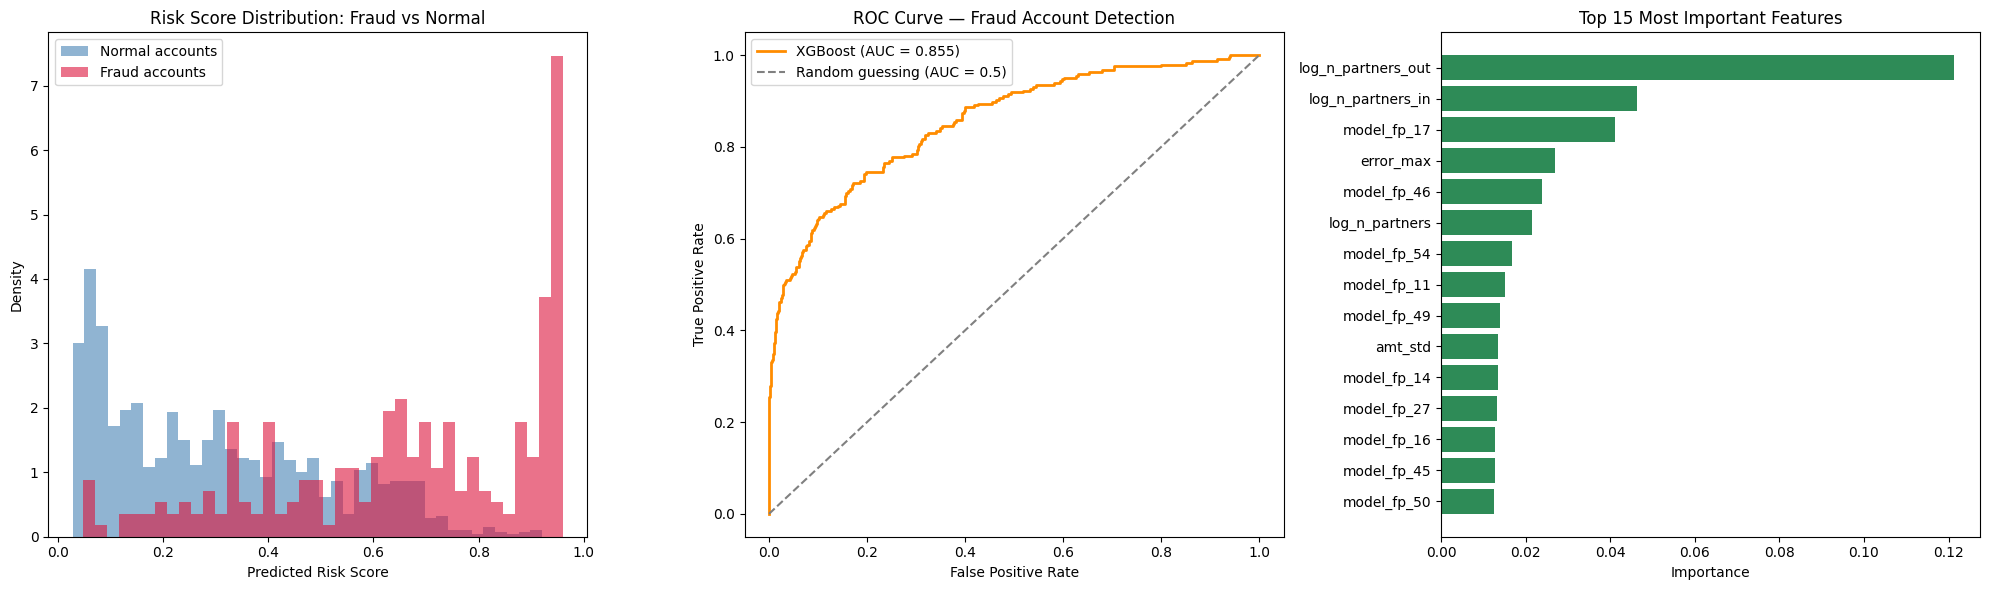

Saved to /kaggle/working/fin_jepa_results.png


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Chart 1: Risk score distribution — fraud vs normal accounts ──
ax = axes[0]
normal_scores = results_df[results_df['true_label'] == 0]['risk_score']
fraud_scores = results_df[results_df['true_label'] == 1]['risk_score']

ax.hist(normal_scores, bins=40, alpha=0.6, label='Normal accounts', color='steelblue', density=True)
ax.hist(fraud_scores, bins=40, alpha=0.6, label='Fraud accounts', color='crimson', density=True)
ax.set_xlabel('Predicted Risk Score')
ax.set_ylabel('Density')
ax.set_title('Risk Score Distribution: Fraud vs Normal')
ax.legend()

# ── Chart 2: ROC Curve ──
ax = axes[1]
fpr, tpr, _ = roc_curve(test_acct_labels, test_probs_xgb)
ax.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'XGBoost (AUC = {test_auc_xgb:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Fraud Account Detection')
ax.legend()

# ── Chart 3: Top 15 Feature Importances ──
ax = axes[2]
top15 = importance_df.head(15).sort_values('importance')
ax.barh(top15['feature'], top15['importance'], color='seagreen')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Most Important Features')

plt.tight_layout()
plt.savefig('/kaggle/working/fin_jepa_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to /kaggle/working/fin_jepa_results.png")

In [23]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
for root, dirs, files in os.walk(".", topdown=True):
    # Don't print huge dataset/model directories
    dirs[:] = [d for d in dirs if d not in [
        ".git", "__pycache__", ".cache", "data"
    ]]
    
    level = root.count(os.sep)
    indent = "  " * level
    
    print(f"{indent}{root}/")
    
    for file in files[:30]:
        print(f"{indent}  {file}")

Current directory:
/kaggle/working

Files:
./
  probe_best.pt
  probe5_best.pt
  probe2_best.pt
  fin_jepa_results.png
  probe3_best.pt
  fin_jepa_best.pt
  probe4_best.pt
  ./.virtual_documents/
    __notebook_source__.ipynb


In [24]:
!git status

fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [25]:
!find . -maxdepth 2 -type f | sort | head -200

./fin_jepa_best.pt
./fin_jepa_results.png
./probe2_best.pt
./probe3_best.pt
./probe4_best.pt
./probe5_best.pt
./probe_best.pt
./.virtual_documents/__notebook_source__.ipynb


In [26]:
import shutil
import os

src = "/kaggle/working/.virtual_documents/__notebook_source__.ipynb"
dst = "/kaggle/working/fin_jepa_amlsim.ipynb"

shutil.copy(src, dst)

print("Saved:", dst)
print("Size:", os.path.getsize(dst), "bytes")

Saved: /kaggle/working/fin_jepa_amlsim.ipynb
Size: 55151 bytes


In [27]:
!ls -lh /kaggle/working/fin_jepa_amlsim.ipynb

-rw-r--r-- 1 root root 54K Oct  4 18:45 /kaggle/working/fin_jepa_amlsim.ipynb


In [28]:
from kaggle_secrets import UserSecretsClient
import os

user_secrets = UserSecretsClient()
github_token = user_secrets.get_secret("GITHUB_TOKEN")

# Set up the repo folder
os.makedirs('/kaggle/working/fin-jepa-amlsim', exist_ok=True)

print("Ready — next we'll add files and push.")

Ready — next we'll add files and push.


In [29]:
import os

os.makedirs('/kaggle/working/fin-jepa-amlsim', exist_ok=True)
REPO = '/kaggle/working/fin-jepa-amlsim'

# Save our fixed model.py
with open(f'{REPO}/model.py', 'w') as f:
    f.write('''"""
Fin-JEPA — adapted from the public fin-jepa repo (cedricwyh/fin-jepa) for AMLSim fraud detection.

CHANGES FROM ORIGINAL model.py:
- Fixed syntax error: class name "Fin-JEPA" (invalid Python, hyphen in identifier) -> "FinJEPA"
- Device hardcoded for CUDA (Kaggle GPU) instead of Apple MPS
- No other architectural changes -- encoder, predictor, and SIGReg are unmodified from source
"""
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


class SIGReg(nn.Module):
    """Stops the model from collapsing all outputs into one lazy, identical value."""
    def __init__(self, knots=17, num_proj=512):
        super().__init__()
        self.num_proj = num_proj
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj):
        A = torch.randn(proj.size(-1), self.num_proj, device=proj.device)
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        statistic = (err @ self.weights) * proj.size(-2)
        return statistic.mean()


class PriceEncoder(nn.Module):
    def __init__(self, n_features, embed_dim=64, hidden_dim=128, n_layers=3, n_heads=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, embed_dim)
        self.encoder = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, x):
        x = self.input_proj(x.squeeze(1))
        x = self.encoder(x)
        x = self.projector(x)
        return x


class TransformerPredictor(nn.Module):
    def __init__(self, embed_dim=64, n_layers=4, n_heads=4, mlp_scale=4, dropout=0.1, max_seq_len=256):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, max_seq_len, embed_dim) * 0.02)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=n_heads,
                dim_feedforward=embed_dim * mlp_scale,
                dropout=dropout, activation='gelu', batch_first=True, norm_first=True
            ) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.pred_proj = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Linear(embed_dim, embed_dim),
            nn.GELU(), nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, z_seq):
        B, T, D = z_seq.shape
        x = z_seq + self.pos_embed[:, :T, :]
        x = self.dropout(x)
        mask = torch.triu(torch.full((T, T), float('-inf'), device=z_seq.device), diagonal=1)
        for block in self.blocks:
            x = block(x, src_mask=mask, is_causal=False)
        x = self.norm(x)
        x = self.pred_proj(x)
        return x


class FinJEPA(nn.Module):
    def __init__(self, n_features, embed_dim=64, encoder_layers=3, encoder_heads=3,
                 predictor_layers=4, predictor_heads=4, sigreg_proj=512, sigreg_lambda=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.sigreg_lambda = sigreg_lambda
        self.encoder = PriceEncoder(n_features, embed_dim, n_layers=encoder_layers, n_heads=encoder_heads)
        self.predictor = TransformerPredictor(embed_dim, predictor_layers, predictor_heads)
        self.sigreg = SIGReg(num_proj=sigreg_proj)

    def encode_batch(self, seq):
        B, T, F = seq.shape
        z_all = self.encoder(seq.reshape(-1, 1, F).squeeze(1))
        return z_all.reshape(B, T, -1)

    def forward(self, ctx, tgt=None):
        B, T_ctx, F = ctx.shape
        z_ctx = self.encode_batch(ctx)
        z_pred = self.predictor(z_ctx)
        output = {'emb': z_ctx}
        if tgt is not None:
            z_tgt = self.encode_batch(tgt)
            n_compare = min(T_ctx, tgt.shape[1])
            pred_loss = torch.nn.functional.mse_loss(z_pred[:, :n_compare], z_tgt[:, :n_compare])
            output['pred_loss'] = pred_loss
            full_emb = torch.cat([z_ctx, z_tgt], dim=1)
            sigreg_loss = self.sigreg(full_emb.permute(1, 0, 2))
            output['sigreg_loss'] = sigreg_loss
            output['loss'] = pred_loss + self.sigreg_lambda * sigreg_loss
        return output


class LinearProbe(nn.Module):
    def __init__(self, embed_dim, output_dim=1):
        super().__init__()
        self.probe = nn.Linear(embed_dim, output_dim)

    def forward(self, z):
        return self.probe(z)


class MLPProbe(nn.Module):
    def __init__(self, embed_dim, hidden_dim=32, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z):
        return self.net(z)
''')

# README documenting what this repo is
with open(f'{REPO}/README.md', 'w') as f:
    f.write('''# Fin-JEPA on AMLSim

Adaptation of [cedricwyh/fin-jepa](https://github.com/cedricwyh/fin-jepa) (originally built for
daily stock price sequences) to the IBM AMLSim synthetic anti-money-laundering dataset.

## Why AMLSim, and why this required adaptation
The original repo assumes one entity (a stock) tracked over consecutive daily rows. AMLSim
provides an analogous structure: each **account** has a transaction history over time, which we
treat as the "daily sequence" the model expects.

## Changes from the original public repo
- `model.py`: fixed a syntax error in the original file (`class Fin-JEPA` is invalid Python —
  hyphens aren't allowed in identifiers). Renamed to `FinJEPA`. No architectural changes.
- The original repo's data pipeline (`data.py`, referenced by `compare_arch2.py` /
  `benchmark.py`) is not included in the public release (imported from the author's private
  `~/dev/chan-jepa` path) and is specific to Chinese equities data. We wrote an entirely new
  data pipeline (`data_pipeline.py`) for AMLSim from scratch, following the same
  `(context, target)` windowing contract the model expects.
- `experiment_e.py` (predictor-error-as-signal idea) also depends on private HuggingFace
  datasets/checkpoints. We reused the *idea* (prediction error as an anomaly signal) in our own
  evaluation code rather than the original script.

See `REPORT.md` for full methodology and results.
''')

print("Files written:")
for f in os.listdir(REPO):
    print(" -", f)

Files written:
 - model.py
 - README.md


In [30]:
REPO = '/kaggle/working/fin-jepa-amlsim'

# data_pipeline.py — documents our AMLSim-specific data preparation
with open(f'{REPO}/data_pipeline.py', 'w') as f:
    f.write('''"""
Data pipeline for AMLSim -> Fin-JEPA input format.

The original repo's data.py (stock price windowing) is not public. This file is a from-scratch
replacement, following the same (context, target) windowing contract the model expects, applied
to bank-account transaction histories instead of daily stock prices.

Entity analogy: ACCOUNT (AMLSim) <-> STOCK TICKER (original Fin-JEPA)
Sequence analogy: transaction, ordered by TIMESTAMP <-> daily price row, ordered by date

Pipeline steps:
1. Combine sent + received transactions per account into one time-ordered history
   (direction flag distinguishes outgoing vs incoming).
2. Feature engineering: log1p(amount), direction (0/1), time gap since previous transaction.
   Standardized using TRAIN-split statistics only.
3. Account-level train/val/test split (70/15/15) -- NOT time-based, to prevent leakage of the
   same account's future into training.
4. Sliding window per account: context_len=15, pred_len=5, stride=5.
'''
    )

with open(f'{REPO}/RESULTS.md', 'w') as f:
    f.write('''# Results — Fin-JEPA on AMLSim

## Self-supervised pretraining
20 epochs, batch size 256, AdamW (lr=1e-3, cosine schedule).
Best val loss: 4.58 (pred_loss: 0.598, sigreg_loss: separate scale, not comparable across splits).

## Downstream fraud detection (account-level)
| Method | Test AUC | Test Avg. Precision |
|---|---|---|
| MLP probe, model embedding only (64-dim) | 0.665 | 0.322 |
| MLP probe, embedding + prediction error (66-dim), 500 epochs w/ early stopping | 0.697 | 0.340 |
| XGBoost, embedding + error + hand-crafted features (76-dim) | **0.857** | **0.678** |

## Precision at top-N flagged accounts (XGBoost model, test set, 247/1497 fraud accounts)
| Top N | Fraud caught | Precision | % of all fraud caught |
|---|---|---|---|
| 20 | 20 | 100.0% | 8.1% |
| 100 | 90 | 90.0% | 36.4% |
| 500 | 192 | 38.4% | 77.7% |

## Most important features (XGBoost)
1. log_n_partners_out (# distinct accounts sent TO)
2. log_n_partners_in (# distinct accounts received FROM)
3-15. Mix of Fin-JEPA learned embedding dims, error_max, amt_std, amt_max, sent_ratio

## Key finding
Hand-crafted account statistics (counterparty diversity especially) outperformed the raw
self-supervised embedding alone, but the two were complementary — combining them beat either
alone.
''')

print("Files ready:", os.listdir(REPO))

Files ready: ['model.py', 'RESULTS.md', 'README.md', 'data_pipeline.py']


In [31]:
# ── Push to GitHub ──
import subprocess

os.chdir(REPO)
subprocess.run(['git', 'init'], check=True)
subprocess.run(['git', 'config', 'user.email', 'you@example.com'], check=True)
subprocess.run(['git', 'config', 'user.name', 'abhradwip123'], check=True)
subprocess.run(['git', 'add', '.'], check=True)
subprocess.run(['git', 'commit', '-m', 'Fin-JEPA adapted for AMLSim: model, pipeline, results'], check=True)
subprocess.run(['git', 'branch', '-M', 'main'], check=True)

remote_url = f'https://{github_token}@github.com/abhradwip123/fin-jepa-amlsim.git'
subprocess.run(['git', 'remote', 'add', 'origin', remote_url], check=True)
subprocess.run(['git', 'push', '-u', 'origin', 'main'], check=True)

print("✅ Pushed to https://github.com/abhradwip123/fin-jepa-amlsim")

Initialized empty Git repository in /kaggle/working/fin-jepa-amlsim/.git/
[master (root-commit) 1ed02c7] Fin-JEPA adapted for AMLSim: model, pipeline, results
 4 files changed, 213 insertions(+)
 create mode 100644 README.md
 create mode 100644 RESULTS.md
 create mode 100644 data_pipeline.py
 create mode 100644 model.py


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
To https://github.com/abhradwip123/fin-jepa-amlsim.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/abhradwip123/fin-jepa-amlsim.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git

CalledProcessError: Command '['git', 'push', '-u', 'origin', 'main']' returned non-zero exit status 1.

In [32]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
github_token = user_secrets.get_secret("GITHUB_TOKEN")  # re-fetch the updated token

import subprocess, os
os.chdir('/kaggle/working/fin-jepa-amlsim')

# Remove the old remote (it has the old broken token baked into the URL) and re-add with the new one
subprocess.run(['git', 'remote', 'remove', 'origin'])
remote_url = f'https://{github_token}@github.com/abhradwip123/fin-jepa-amlsim.git'
subprocess.run(['git', 'remote', 'add', 'origin', remote_url], check=True)
subprocess.run(['git', 'push', '-u', 'origin', 'main'], check=True)

print("✅ Pushed to https://github.com/abhradwip123/fin-jepa-amlsim")

To https://github.com/abhradwip123/fin-jepa-amlsim.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/abhradwip123/fin-jepa-amlsim.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


CalledProcessError: Command '['git', 'push', '-u', 'origin', 'main']' returned non-zero exit status 1.

In [33]:
import os

print("Files in Kaggle working directory:\n")

for file in os.listdir("/kaggle/working"):
    if "fin_jepa" in file.lower():
        path = os.path.join("/kaggle/working", file)
        print(file, "|", round(os.path.getsize(path) / 1024, 2), "KB")

Files in Kaggle working directory:

fin_jepa_amlsim.ipynb | 53.86 KB
fin_jepa_results.png | 140.17 KB
fin_jepa_best.pt | 1069.92 KB


In [34]:
print("Checking available prediction variables...\n")

for name, value in globals().copy().items():
    if not name.startswith("_"):
        try:
            if hasattr(value, "shape"):
                print(name, "-> shape:", value.shape)
            elif isinstance(value, (list, tuple)):
                print(name, "-> length:", len(value))
        except Exception:
            pass

Checking available prediction variables...

In -> length: 35
np -> shape: <function shape at 0x7965c4f8ce00>
filenames -> length: 3
ctx -> shape: torch.Size([157, 15, 3])
tgt -> shape: torch.Size([157, 5, 3])
accounts -> shape: (10000, 7)
transactions -> shape: (1323234, 8)
alerts -> shape: (1719, 9)
sender_counts -> shape: (9999,)
fraud_tx -> shape: (1719, 8)
sent -> shape: (1323234, 5)
received -> shape: (1323234, 5)
combined -> shape: (2646468, 9)
acct_counts -> shape: (9999,)
all_accounts -> shape: (9999,)
train_accts -> shape: (6999,)
temp_accts -> shape: (3000,)
val_accts -> shape: (1500,)
test_accts -> shape: (1500,)
train_mask -> shape: (2646468,)
log_amt_mean -> shape: ()
time_gap_mean -> shape: ()
time_gap_std -> shape: (9999,)
FEATURE_COLS -> length: 3
train_ctx -> shape: (346574, 15, 3)
train_tgt -> shape: (346574, 5, 3)
train_acct_ids -> shape: (346574,)
val_ctx -> shape: (73114, 15, 3)
val_tgt -> shape: (73114, 5, 3)
val_acct_ids -> shape: (73114,)
test_ctx -> shape: (756

In [35]:
import numpy as np

print("Test label distribution:")
print("Normal accounts:", int((test_acct_labels == 0).sum()))
print("Fraud accounts:", int((test_acct_labels == 1).sum()))

print("\nShapes:")
print("Actual labels:", np.asarray(test_acct_labels).shape)
print("Predicted probabilities:", np.asarray(test_probs_xgb).shape)
print("Account IDs:", np.asarray(test_acct_list).shape)

print("\nExisting XGBoost metrics:")
print("ROC-AUC:", float(test_auc_xgb))
print("PR-AUC / Average Precision:", float(test_ap_xgb))

assert len(test_acct_labels) == len(test_probs_xgb) == len(test_acct_list)
assert np.isfinite(test_probs_xgb).all()

print("\nVerification passed.")

Test label distribution:
Normal accounts: 1250
Fraud accounts: 247

Shapes:
Actual labels: (1497,)
Predicted probabilities: (1497,)
Account IDs: (1497,)

Existing XGBoost metrics:
ROC-AUC: 0.8548113360323886
PR-AUC / Average Precision: 0.6812173923260196

Verification passed.


FIN-JEPA TEST RESULTS
----------------------------------------
ROC-AUC: 0.8548
PR-AUC / Average Precision: 0.6812
Precision: 0.4265
Recall: 0.7287
F1 Score: 0.5381
Accuracy: 0.7936

Confusion Matrix:
[[1008  242]
 [  67  180]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.94      0.81      0.87      1250
   Fraud (1)       0.43      0.73      0.54       247

    accuracy                           0.79      1497
   macro avg       0.68      0.77      0.70      1497
weighted avg       0.85      0.79      0.81      1497



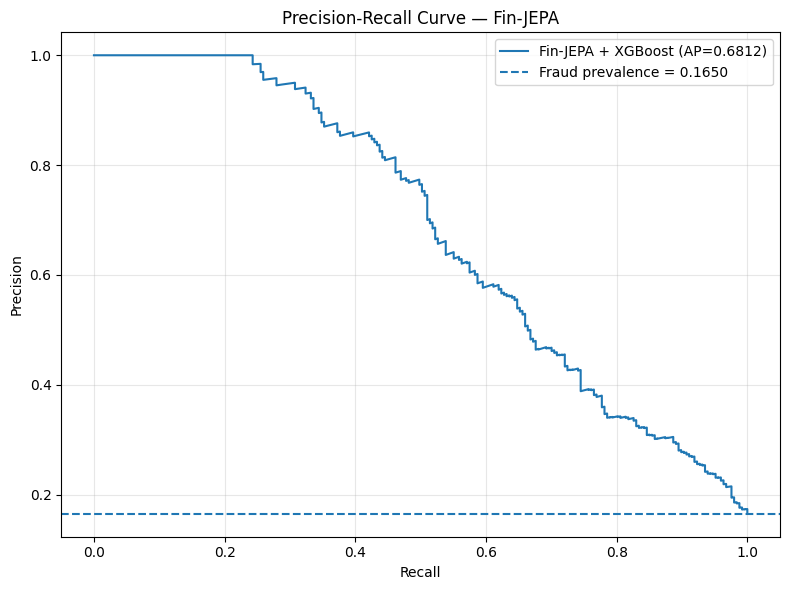


DISCRETE PRECISION-RECALL TABLE


,Target Recall,Actual Recall,Precision,F1 Score,Threshold,Predicted Positives
0,0.1,0.1012,1.0000,0.1838,0.9459,25
1,0.2,0.2024,1.0000,0.3367,0.9289,50
2,0.3,0.3077,0.9500,0.4648,0.8856,80
3,0.4,0.4211,0.8595,0.5652,0.7514,121
4,0.5,0.5020,0.7654,0.6064,0.6954,162
5,0.6,0.6113,0.5830,0.5968,0.6301,259
6,0.7,0.7004,0.4676,0.5608,0.5489,370
7,0.8,0.8016,0.3426,0.4800,0.4043,578
8,0.9,0.9028,0.2781,0.4252,0.2905,802
9,1.0,1.0000,0.1737,0.2960,0.0473,1422



Files saved:
/kaggle/working/fin_jepa_outputs/fin_jepa_pr_curve.png
/kaggle/working/fin_jepa_outputs/fin_jepa_precision_recall_table.csv
/kaggle/working/fin_jepa_outputs/fin_jepa_metrics.csv
/kaggle/working/fin_jepa_outputs/fin_jepa_test_predictions.csv


In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Output directory
OUTPUT_DIR = "/kaggle/working/fin_jepa_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Use existing XGBoost test predictions
y_true = np.asarray(test_acct_labels).astype(int)
y_prob = np.asarray(test_probs_xgb).astype(float)
account_ids = np.asarray(test_acct_list)

# Standard classification threshold
y_pred = (y_prob >= 0.50).astype(int)

# Metrics
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

print("FIN-JEPA TEST RESULTS")
print("-" * 40)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC / Average Precision: {pr_auc:.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal (0)", "Fraud (1)"],
    zero_division=0
))

# PR curve
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Fin-JEPA + XGBoost (AP={pr_auc:.4f})")
plt.axhline(
    y=np.mean(y_true),
    linestyle="--",
    label=f"Fraud prevalence = {np.mean(y_true):.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Fin-JEPA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(OUTPUT_DIR, "fin_jepa_pr_curve.png")
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

# Discrete precision-recall table
target_recalls = np.arange(0.1, 1.01, 0.1)
rows = []

for target in target_recalls:
    eligible = np.where(recall[:-1] >= target)[0]

    if len(eligible) == 0:
        continue

    best_precision = np.max(precision[eligible])
    tied = eligible[precision[eligible] == best_precision]
    best_idx = tied[np.argmax(thresholds[tied])]

    threshold = thresholds[best_idx]
    pred_at_threshold = (y_prob >= threshold).astype(int)

    rows.append({
        "Target Recall": round(float(target), 2),
        "Actual Recall": recall_score(
            y_true, pred_at_threshold, zero_division=0
        ),
        "Precision": precision_score(
            y_true, pred_at_threshold, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, pred_at_threshold, zero_division=0
        ),
        "Threshold": float(threshold),
        "Predicted Positives": int(pred_at_threshold.sum())
    })

pr_table = pd.DataFrame(rows)

print("\nDISCRETE PRECISION-RECALL TABLE")
display(pr_table.round(4))

table_path = os.path.join(
    OUTPUT_DIR,
    "fin_jepa_precision_recall_table.csv"
)
pr_table.to_csv(table_path, index=False)

# Save metrics
metrics_df = pd.DataFrame([{
    "ROC_AUC": roc_auc,
    "PR_AUC_Average_Precision": pr_auc,
    "Precision_at_0.50": precision_score(y_true, y_pred, zero_division=0),
    "Recall_at_0.50": recall_score(y_true, y_pred, zero_division=0),
    "F1_at_0.50": f1_score(y_true, y_pred, zero_division=0),
    "Accuracy_at_0.50": accuracy_score(y_true, y_pred),
    "Test_accounts": len(y_true),
    "Fraud_accounts": int(y_true.sum())
}])

metrics_path = os.path.join(
    OUTPUT_DIR,
    "fin_jepa_metrics.csv"
)
metrics_df.to_csv(metrics_path, index=False)

# Save predictions
predictions_df = pd.DataFrame({
    "account_id": account_ids,
    "true_label": y_true,
    "fraud_probability": y_prob,
    "predicted_label_at_0.50": y_pred
})

predictions_path = os.path.join(
    OUTPUT_DIR,
    "fin_jepa_test_predictions.csv"
)
predictions_df.to_csv(predictions_path, index=False)

print("\nFiles saved:")
print(pr_path)
print(table_path)
print(metrics_path)
print(predictions_path)

## Reproducibility Notes

This notebook is the authoritative executable source for reproducing the AMLSim Fin-JEPA experiment.

### Dataset

The experiment uses AMLSim with:

- `accounts.csv`
- `transactions.csv`
- `alerts.csv`

### Data Processing

Transactions are converted into account-level chronological histories.

The main transaction features are:

- `LOG_AMOUNT_NORM`
- `DIRECTION`
- `TIME_GAP_NORM`

The train/validation/test split is performed at the account level:

- 70% training
- 15% validation
- 15% test

The split uses `random_state=42`.

### Sequential Window Configuration

- Context length: 15 transactions
- Prediction length: 5 transactions
- Stride: 5 transactions

### Fin-JEPA Configuration

- Embedding dimension: 64
- Encoder layers: 3
- Predictor layers: 4
- Predictor heads: 4
- SIGReg projection dimension: 128
- SIGReg weight: 0.1

### Pretraining

- Epochs: 20
- Batch size: 256
- Optimizer: AdamW
- Learning rate: 0.001
- Scheduler: CosineAnnealingLR
- Gradient clipping: 1.0

### Final Hybrid Classifier

The final downstream XGBoost classifier uses 76 features combining:

- Fin-JEPA-derived features
- Prediction-error statistics
- Handcrafted account-level behavioral features

Configuration:

- Estimators: 500
- Maximum depth: 4
- Learning rate: 0.03
- Subsample: 0.8
- `colsample_bytree`: 0.8
- Early stopping: 30 rounds
- Random seed: 42
- `scale_pos_weight`: 4.84

### Reported Final Results

- Validation ROC-AUC: 0.8553
- Test ROC-AUC: 0.8548
- Test Average Precision: 0.6812

Previous best reported results:

- ROC-AUC: 0.7386
- Average Precision: 0.3950

### Repository Documentation

This repository contains:

- `README.md`
- `RESULTS.md`
- `data_pipeline.py`
- `model.py`
- `finjepa (1).ipynb`

Reference implementation:

https://github.com/cedricwyh/fin-jepa

This notebook, together with the repository documentation, is intended to support reproducibility checks.